# Parte 2 – Mapas del Perú

Graficar mapas con Geopandas y Folium partiendo de las plantillas de la sesión 7

*Pistas:* 

*- Si usan Folium, recuerden no guardar el notebook con salidas pesadas que aumenten el peso del repositorio.*

*- Si algún mapa no pinta, revisen que la columna de unión (ubigeo) sea de tipo texto y mantenga el cero a la izquierda.*

## 2.1. Paso 1: 

**Enunciado**: Asegúrense de contar con el código de ubigeo (texto de 2 dígitos, e.g. '01') o el nombre del departamento en su dataset para enlazar con las geometrías oficiales.



In [1]:
# Primero se importa la librería pandas para poder trabajar con dataframes
import pandas as pd

In [2]:
datos = pd.read_csv("datos/tabla_final.csv", dtype={"ubigeo": str})
datos.head()


,ubigeo,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
0,01,Amazonas,Chachapoyas,-6.23169,-77.86903,427.9,0,8,4
1,02,Áncash,Huaraz,-9.52614,-77.52869,1415.9,11,8,6
2,03,Apurímac,Abancay,-13.63426,-72.88380,820.0,3,7,2
3,04,Arequipa,Arequipa,-16.39899,-71.53747,439.4,3,8,2
4,05,Ayacucho,Ayacucho,-13.16380,-74.22345,500.8,1,8,4


Se identifica que los ubigeos tienen el código de ubigeo de 2 dígitos. Para asegurar esta información, se van a usar las siguientes funciones:

In [3]:
(datos["ubigeo"].str.len() == 2).all()

np.True_

In [4]:
datos["ubigeo"].dtype

dtype('O')

Con ello, se confirma que todos los ubigeos tienen 2 dígitos y que la columna está en formato texto.

## 2.2 Paso 2

**Enunciado**: Carguen el GeoJSON o Shapefile departamental facilitado en la sesión 7/8 (distritos.geojson o el descargado con
fetch_data.py 07-mapas) y únanlo con sus datos.

Primero, se verifica si departamentos_peru.geojson tiene la variable ubigeo.

In [5]:
# Se importa geopandas y se revisa el archivo de departamentos de la clase

import geopandas as gpd

rev_departamentos = gpd.read_file("datos/departamentos_peru.geojson")
print(rev_departamentos.shape)
print(rev_departamentos.columns.tolist())
rev_departamentos.head()

(25, 2)
['departamento', 'geometry']


,departamento,geometry
0,AMAZONAS,"POLYGON ((-78.03025 -6.7661, -78.04983 -6.6838..."
1,ANCASH,"POLYGON ((-77.69239 -10.3209, -77.75251 -10.32..."
2,APURIMAC,"POLYGON ((-73.51174 -14.53852, -73.52075 -14.5..."
3,AREQUIPA,"POLYGON ((-72.72968 -16.64631, -72.77421 -16.6..."
4,AYACUCHO,"POLYGON ((-74.50188 -15.16058, -74.51267 -15.1..."


Entonces, debido a que departamentos_peru.geojson no tiene ubigeo, se va a usar distritos_peru.geojson para generar una variable de ubigeo departamental, y con ello, lograr agrupar los polígonos a nivel departamental.

In [6]:
# Se revisa el archivo de distritos

distritos = gpd.read_file("datos/distritos_peru.geojson")

# Luego, se crea el código de departamento a partir de los primeros 2 dígitos del ubigeo.

distritos["ubigeo_dep"] = distritos["ubigeo"].str[:2]

# Se agruparán los distritos en un solo polígono por departamento.

mapa_dep = distritos[["ubigeo_dep", "geometry"]].dissolve(by="ubigeo_dep", as_index=False)
mapa_dep = mapa_dep.rename(columns={"ubigeo_dep": "ubigeo"})

# Por último, se cierran los huecos diminutos que deja el dissolve entre distritos vecinos (se veían como puntos blancos en el mapa del paso 3): se pasa a metros (EPSG:32718), se agranda y achica 100 m, y se vuelve a grados.

mapa_dep = mapa_dep.to_crs(32718)
mapa_dep["geometry"] = mapa_dep.buffer(100).buffer(-100)
mapa_dep = mapa_dep.to_crs(4326)

mapa_dep.shape

(25, 2)

Antes de unir la tabla al mapa, se debe verificar que cuadren los datos del mapa y la tabla.

In [7]:
# Se verifica que el tipo de la columna ubigeo sea el mismo en ambos dataframes.
print("Mapa :", mapa_dep["ubigeo"].dtype, "| ejemplo:", mapa_dep["ubigeo"].iloc[0])
print("Tabla:", datos["ubigeo"].dtype, "| ejemplo:", datos["ubigeo"].iloc[0])

# Ahora, se va a contar cuántos ubigeos coinciden entre el mapa y la tabla.
print("Coinciden:", len(set(mapa_dep["ubigeo"]) & set(datos["ubigeo"])), "de", len(datos))
print("En el mapa, pero no en la tabla:", set(mapa_dep["ubigeo"]) - set(datos["ubigeo"]))
print("En la tabla, pero no en el mapa:", set(datos["ubigeo"]) - set(mapa_dep["ubigeo"]))

Mapa : object | ejemplo: 01
Tabla: object | ejemplo: 01
Coinciden: 25 de 25
En el mapa, pero no en la tabla: set()
En la tabla, pero no en el mapa: set()


Se verifica que el ubigeo es texto de 2 dígitos en ambos lados y que los 25 departamentos coinciden, sin ubigeos sin cruzar. Por último, se unen los datos de la tabla al mapa.

In [8]:
# Se une la tabla de datos al mapa, por ubigeo
mapa = mapa_dep.merge(datos, on="ubigeo", how="left")

# Se verifica la unión.
print(mapa.shape)
print("Vacíos:", mapa["declaratorias"].isna().sum())
print("Total en la tabla:", datos["declaratorias"].sum(), "| en el mapa:", mapa["declaratorias"].sum())

(25, 10)
Vacíos: 0
Total en la tabla: 157 | en el mapa: 157


Se generó el mapa de 25 departamentos y se verificó que quedó sin vacíos y con el mismo total de declaratorias de emergencia que la tabla (157)


## 2.3. Paso 3

**Enunciado**: Hagan un mapa estático con Geopandas (coropleta con .plot(column=...))

Se harán dos mapas por cuantiles: uno de lluvia total y otro de declaratorias de emergencia, para compararlos (Fuente: Open-Meteo (lluvia) y PCM-gob.pe (declaratorias)).

Pero, primero, se va a definir la paleta de colores y contorno del mapa del Perú, con la finalidad que se visualice bien los quintiles en el mapa.

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.patheffects as pe

# Se crean paletas que empiezan en un tono visible (30 %) y no en casi blanco, con 5 colores (uno por grupo)

azules = ListedColormap(plt.cm.Blues(np.linspace(0.3, 1, 5)))
rojos = ListedColormap(plt.cm.OrRd(np.linspace(0.3, 1, 5)))

# Se crea el contorno del Perú: se juntan los 25 departamentos en una sola forma

contorno = mapa.to_crs(32718).dissolve()
contorno["geometry"] = contorno.buffer(500).buffer(-500)
contorno = contorno.to_crs(4326)

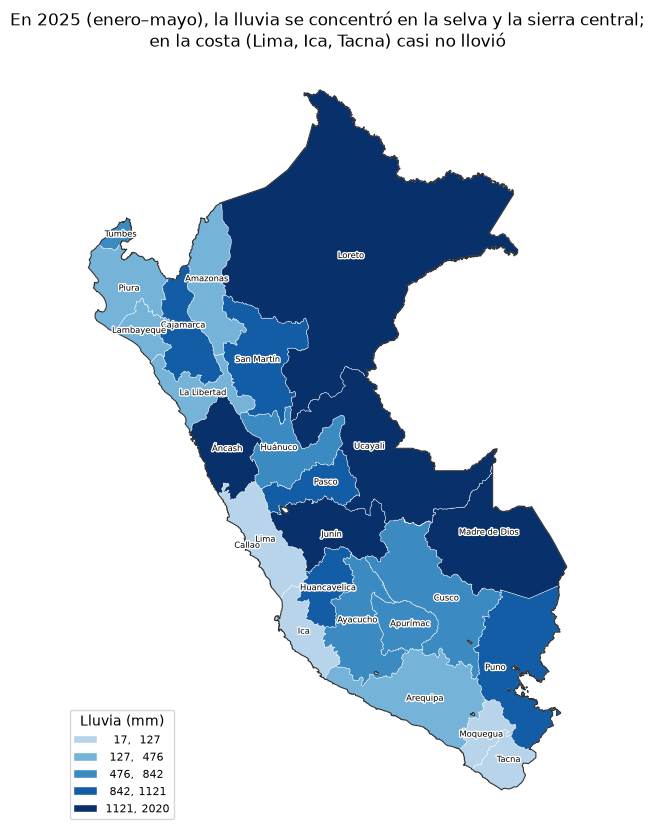

In [10]:
# Se grafica el mapa de lluvia total por departamento
ax = mapa.plot(column="lluvia_total_mm", cmap=azules, figsize=(8, 10),
               scheme="quantiles", k=5, legend=True,
               edgecolor="white", linewidth=0.3,
               legend_kwds={"loc": "lower left", "fontsize": 8, "title": "Lluvia (mm)", "fmt": "{:.0f}"})
contorno.boundary.plot(ax=ax, color="#333333", linewidth=0.8)
# Se agrega el nombre de cada departamento
for _, fila in mapa.iterrows():
    punto = fila["geometry"].representative_point()
    ax.annotate(fila["departamento"], xy=(punto.x, punto.y), ha="center", va="center",
                fontsize=6, path_effects=[pe.withStroke(linewidth=2, foreground="white")])
ax.set_title("En 2025 (enero–mayo), la lluvia se concentró en la selva y la sierra central;\n"
             "en la costa (Lima, Ica, Tacna) casi no llovió", fontsize=12)

ax.set_axis_off()
plt.show()

Ahora, se realizará el mapa de las declaratorias de emergencia.

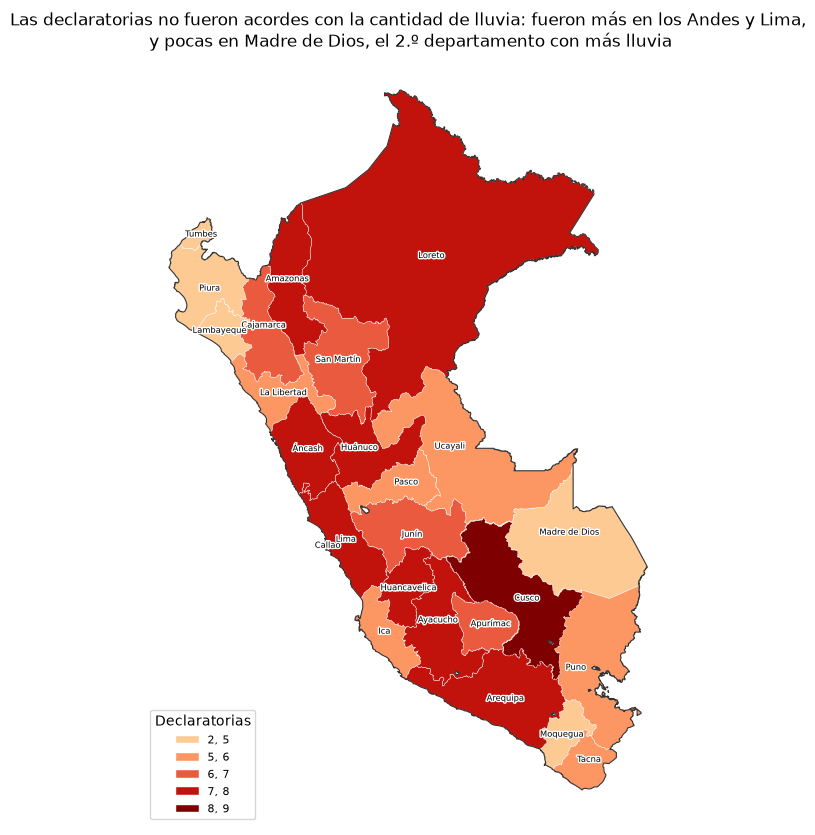

In [11]:
# Se grafica el mapa de declaratorias de emergencia por departamento
ax = mapa.plot(column="declaratorias", cmap=rojos, figsize=(8, 10),
               scheme="quantiles", k=5, legend=True,
               edgecolor="white", linewidth=0.3,
               legend_kwds={"loc": "lower left", "fontsize": 8, "title": "Declaratorias", "fmt": "{:.0f}"})
contorno.boundary.plot(ax=ax, color="#333333", linewidth=0.8)
# Se agrega el nombre de cada departamento
for _, fila in mapa.iterrows():
    punto = fila["geometry"].representative_point()
    ax.annotate(fila["departamento"], xy=(punto.x, punto.y), ha="center", va="center",
                fontsize=6, path_effects=[pe.withStroke(linewidth=2, foreground="white")])
ax.set_title("Las declaratorias no fueron acordes con la cantidad de lluvia: fueron más en los Andes y Lima,\n"
             " y pocas en Madre de Dios, el 2.º departamento con más lluvia", fontsize=12)


ax.set_axis_off()
plt.show()

De acuerdo con lo visualizado en los 2 mapas, se concluye que las declaratorias de emergencia por lluvia no coinciden con la cantidad de lluvia por departamento. Madre de Dios, que es uno de los departamentos con más lluvias en el año 2025, es uno de los departamentos donde menos declaratorias de emergencia se emitieron. En cambio, en Lima, donde llovió muy poco, se emitieron 8 declaratorias de emergencia.

Por otro lado, pese a que el primer mapa muestra que, donde más llueve es en la selva, las declaratorias se emiten principalmente en la sierra.


## 2.4. Paso 4

**Enunciado**: Hagan un mapa interactivo con Folium: utilizando
folium.Choropleth o px.choropleth_map con un tooltip para mostrar el valor al pasar el cursor.

Primero, se van a ejecutar funciones para simplificar los mapas, ya que las formas pesan 10 MB y Folium las incluye dos veces; se simplifican para que el mapa sea liviano (de 10 MB a 0,24 MB).

In [12]:
# Se crea una copia liviana del mapa para Folium: se simplifican los bordes (≈ 1 km de tolerancia).

mapa_web = mapa[["ubigeo", "departamento", "lluvia_total_mm", "declaratorias", "prorrogas", "geometry"]].copy()
mapa_web["geometry"] = mapa_web.simplify(0.01)

In [ ]:
import folium

# Se crea el mapa base centrado en el Perú. Se usa el fondo Esri.WorldGrayCanvas porque CartoDB (el de la plantilla) ahora exige una clave (API key); sugerencia de Claude.

m = folium.Map(location=[-9.2, -75.0], zoom_start=5, tiles="Esri.WorldGrayCanvas")

# Capa de color: declaratorias, con los mismos cortes por cuantiles que el mapa estático
folium.Choropleth(
    geo_data=mapa_web, data=mapa_web,
    columns=["ubigeo", "declaratorias"],
    key_on="feature.properties.ubigeo",
    fill_color="YlOrRd", fill_opacity=0.7, line_opacity=0.3,
    legend_name="Declaratorias de emergencia por lluvias (enero–mayo 2025)",
    bins=mapa_web["declaratorias"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1]).tolist(),
).add_to(m)

# Capa invisible con el tooltip: muestra los datos al pasar el mouse
folium.GeoJson(
    mapa_web,
    style_function=lambda x: {"fillOpacity": 0, "weight": 0},
    tooltip=folium.GeoJsonTooltip(
        fields=["departamento", "declaratorias", "prorrogas", "lluvia_total_mm"],
        aliases=["Departamento:", "Declaratorias:", "Prórrogas:", "Lluvia total (mm):"],
    ),
).add_to(m)

# Se guarda el mapa como página web, para abrirlo en el navegador
m.save("mapa_interactivo.html")

m


## 2.5. Paso 5

**Enunciado**: En una celda de texto breve, comenten qué patrón geográfico resalta en el mapa.

Por un lado, se visualiza que las declaratorias se centran en la sierra peruana, además de Lima, Loreto y Amazonas. Sin embargo, los departamentos más lluviosos se encuentran en la selva. En la costa norte se han emitido pocas declaratorias. Y el caso que representa la mayor evidencia que la emisión de declaratorias, aparentemente, no considera la cantidad de lluvia en mm para emitir los decretos supremos, es Madre de Dios: es uno de los departamentos que más llueve, pero también es uno de los que menos declaratorias de emergencia se emitieron.

Igual, queda pendiente de investigar si esa relación se debe a que hay departamentos que, a nivel de infraestructura, están preparados para recibir una lluvia, mientras que otros no. 

Por otro lado, una de las ventajas es que el mapa de Folium permite ver el valor exacto al pasar el cursor, tanto de la lluvia como de las declaratorias de emergencia. Además, esto facilita evidenciar que no existe una relación directa entre lluvia y declaratorias. Sin embargo, como desventaja, visualmente un departamento grande llama más la atención que uno pequeño aunque tengan el mismo valor; por ejemplo, Loreto y Lima, que tienen 8 declaratorias cada uno.

Asimismo, es importante resaltar que, respecto a los gráficos de la parte 1, se visualiza también que la relación entre lluvia y declaratorias de emergencia no es directa. 